# Datasets

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

In [2]:
ds = load_dataset("angrygiraffe/claude-opus-4.6-4.7-reasoning-8.7k")

In [3]:
def from_openai_format_to_raw_text(messages):
    # Add special tokens to indicate the start of user and assistant messages
    raw_text = ""
    for message in messages:
        if message["role"] == "user":
            raw_text += "<user>" + message["content"] + "</user>"
        elif message["role"] == "assistant":
            raw_text += "</assistant|>" + message["content"] + "</assistant|>"
        elif message["role"] == "system":
            raw_text += "<system>" + message["content"] + "</system>"
        else:
            print(f"Unknown role: {message['role']}")
    return raw_text

In [6]:
# Save dataset to disk
df: pd.DataFrame = ds["train"].to_pandas()
df["processed"] = df["messages"].apply(lambda x: from_openai_format_to_raw_text(x))
# df["input_length_chars"] = df["processed"].apply(len)
# Drop the original messages column
df = df.drop(columns=["messages"])
df.to_csv("claude_opus_4.6_4.7_reasoning_8.7k.csv", index=False)
df

,category,model,processed
0,coding,claude-opus-4-6,<system>You are a computer science tutor. Expl...
1,coding,claude-opus-4-6,<system>You are a computer science tutor. Expl...
2,coding,claude-opus-4-6,<system>You are a DevOps engineer. Focus on re...
3,coding,claude-opus-4-7,<system>You are a senior React/TypeScript engi...
4,coding,claude-opus-4-7,<system>You are an event-driven systems engine...
...,...,...,...
38499,roleplay_villain,claude-opus-4-6,"<system>You are Iago, now speaking separately ..."
38500,roleplay_villain,claude-opus-4-6,<system>You are Cersei Lannister of House Lann...
38501,narrative_prose,claude-opus-4-6,<system>You are a literary fiction writer. Cha...
38502,roleplay_villain,claude-opus-4-6,<system>You are Erik Lehnsherr — Magneto — sea...


/tmp/ipykernel_142192/656795141.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="category", data=df, order=order, palette="viridis")


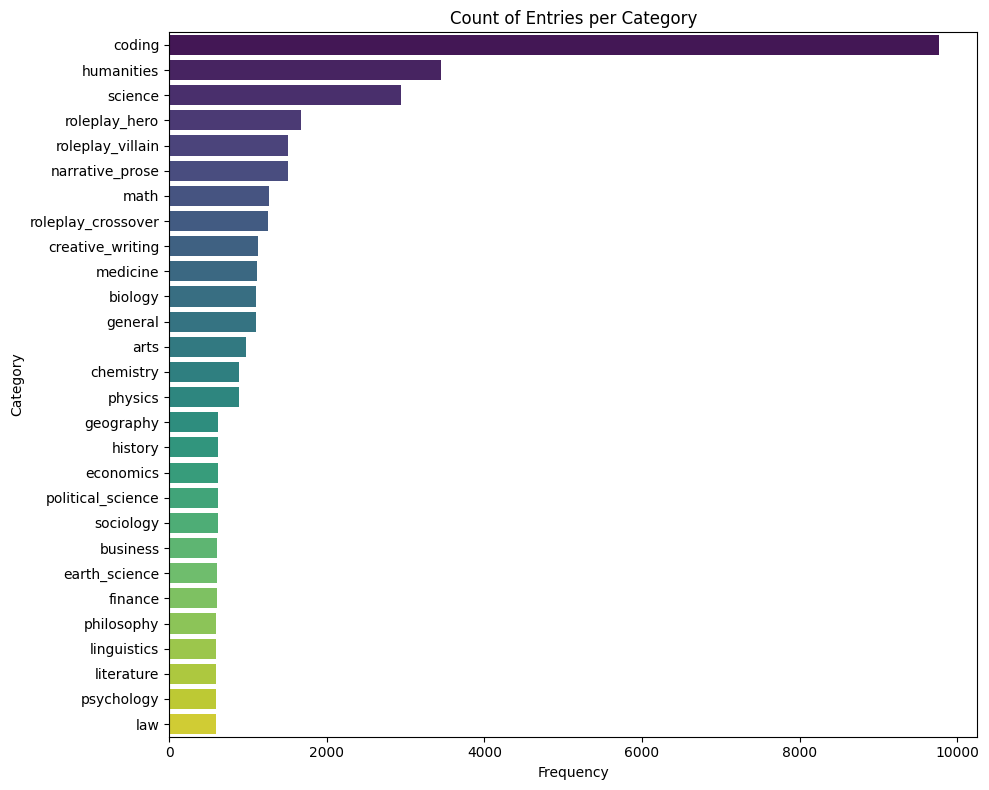

In [30]:
plt.figure(figsize=(10,8))
order = df["category"].value_counts().index
sns.countplot(y="category", data=df, order=order, palette="viridis")
plt.xlabel("Frequency")
plt.ylabel("Category")
plt.title("Count of Entries per Category")
plt.tight_layout()
plt.show()

/tmp/ipykernel_142192/2412648886.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df, x="input_length_chars", bins=20, kde=True, palette="viridis")


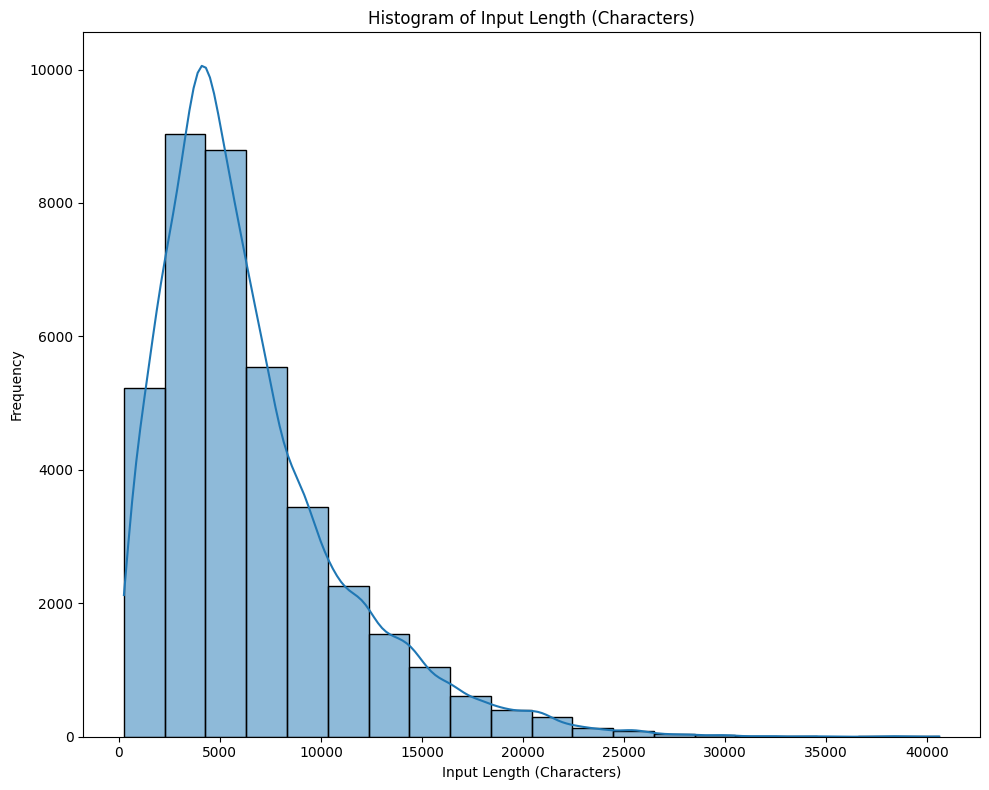

In [31]:
# Plot histogram of the input_length_chars column
plt.figure(figsize=(10, 8))
sns.histplot(data=df, x="input_length_chars", bins=20, kde=True, palette="viridis")
plt.xlabel("Input Length (Characters)")
plt.ylabel("Frequency")
plt.title("Histogram of Input Length (Characters)")
plt.tight_layout()
plt.show()